In [2]:
import json
import pandas as pd
from cbb.scrape import kenpom
from cbb.lib import paths, teams

pd.set_option('display.colheader_justify', 'center')
S16 =  ["Duke", "St. John's", "Michigan St.", "Connecticut", "Arizona", "Arkansas", "Texas", "Purdue", "Michigan", "Alabama", "Tennessee", "Iowa St.", "Iowa", "Nebraska", "Illinois", "Houston"]
M1 = S16[0:2]
M2 = S16[2:4]
M3 = S16[4:6]
M4 = S16[6:8]
M5 = S16[8:10]
M6 = S16[10:12]
M7 = S16[12:14]
M8 = S16[14:16]
TOT_TEAMS = 364

s16_file = paths.M_KEN_DIR / "2026-03-26.json"
with open(s16_file, "r", encoding="utf-8") as f:
    data = json.load(f)

kenpom_data = pd.DataFrame(data["rows"], columns=data["headers"])
tourney_teams = kenpom_data[kenpom_data["Seed"] > 0].sort_values(by="Seed")
tourney_teams = tourney_teams.rename(columns={"TeamName" : "Team"})
tourney_teams["S16"] = tourney_teams["Team"].isin(S16)
def highlight_specific_matchup(row):
    if row['Team'] in M1:
        return ['background-color: yellow'] * len(row)
    elif row['Team'] in M2:
        return ['background-color: salmon'] * len(row)
    elif row['Team'] in M3:
        return ['background-color: goldenrod'] * len(row)
    elif row['Team'] in M4:
        return ['background-color: lightgreen'] * len(row)
    elif row['Team'] in M5:
        return ['background-color: lightpink'] * len(row)
    elif row['Team'] in M6:
        return ['background-color: plum'] * len(row)
    elif row['Team'] in M7:
        return ['background-color: paleturquoise'] * len(row)
    elif row['Team'] in M8:
        return ['background-color: peachpuff'] * len(row)
    else:
        return [''] * len(row)

In [3]:
def logos(row):
    if row['S16'] == 1:
        return teams.getTeamLogoShort(row["Team"])
    else:
        return ''
tourney_teams["logo"] = tourney_teams.apply(lambda x: logos(x), axis =1)

In [4]:
# Free Throw Data 
tourney_teams["FTPercentile"] = 100*((TOT_TEAMS - tourney_teams["RankFTPct"]) / TOT_TEAMS)
s16 = tourney_teams[tourney_teams["S16"] == True]
s16 = s16.rename(columns={"FTPct":"FT %", "RankFTPct" : "Natl. Rank", "FTPercentile" : "Percentile"})
ftr = s16[["Team","Seed", "FT %", "Natl. Rank", "Percentile"]].sort_values(by="FT %", ascending=False)
ftr['Percentile'] = ftr["Percentile"].round(0)
ftr = ftr.style \
    .hide(axis='index') \
    .apply(highlight_specific_matchup, axis=1) \
    .set_properties(**{'text-align': 'center'}).set_table_styles([
        dict(selector='th', props=[('text-align', 'center')]) 
    ]) \
    .format({'FT %': '{:.2%}'}) \
    .format({"Percentile" : "{:.0f}th".format})

ftr

Team,Seed,FT %,Natl. Rank,Percentile
Illinois,3,78.437000,13,96th
Houston,2,77.204700,28,92th
Iowa,9,76.576600,39,89th
Michigan St.,3,76.503500,40,89th
Alabama,4,76.405900,41,89th
Nebraska,4,75.189400,75,79th
Arkansas,4,74.969900,81,78th
Purdue,2,74.881500,90,75th
Texas,11,74.716600,94,74th
Michigan,1,74.692900,96,74th


Adjusted Offensive Efficiency (y) vs Adjusted Defensive Efficiency (x) for all 2026 Tournament Teams

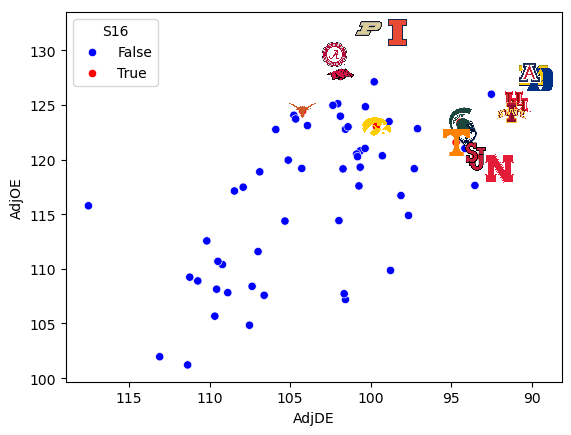

In [5]:
# Efficiency
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

eff = tourney_teams[["Team","Seed", "AdjOE", "AdjDE", 'S16', 'logo']]
fig, ax = plt.subplots()
g = sns.scatterplot(data=eff, x='AdjDE', y='AdjOE', hue='S16', palette={0: 'blue', 1: 'red'})
g.invert_xaxis()  # or g.invert_yaxis()
for i, row in eff.iterrows():
    if row['S16'] == 1:
        # Load image
        path = paths.ASSET_IMG_DIR / row['logo']
        img = plt.imread(path)
        im = OffsetImage(img, zoom=0.04) # Adjust zoom as necessary
        
        # Create AnnotationBbox
        ab = AnnotationBbox(im, (row['AdjDE'], row['AdjOE']), frameon=False)
        ax.add_artist(ab)
plt.show()


Adjusted Offensive Efficiency (y) vs Adjusted Defensive Efficiency (x)

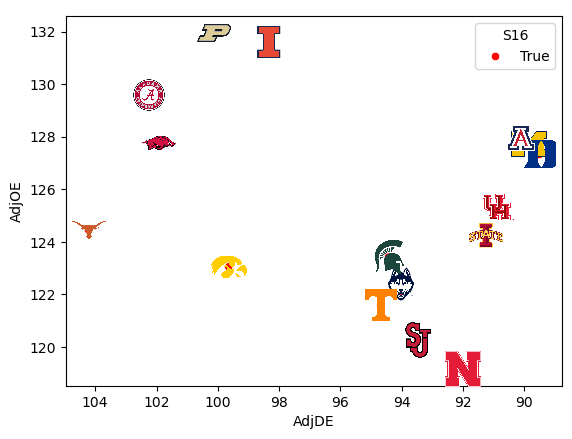

In [6]:
fig, ax = plt.subplots()
g = sns.scatterplot(data=eff[eff['S16'] == 1], x='AdjDE', y='AdjOE', hue='S16', palette={0: 'blue', 1: 'red'})
g.invert_xaxis()  # or g.invert_yaxis()
for i, row in eff.iterrows():
    if row['S16'] == 1:
        # Load image
        path = paths.ASSET_IMG_DIR / row['logo']
        img = plt.imread(path)
        im = OffsetImage(img, zoom=0.05) # Adjust zoom as necessary
        
        # Create AnnotationBbox
        ab = AnnotationBbox(im, (row['AdjDE'], row['AdjOE']), frameon=False)
        ax.add_artist(ab)
plt.show()


3 Pt % - Scored (y) vs Allowed (x)

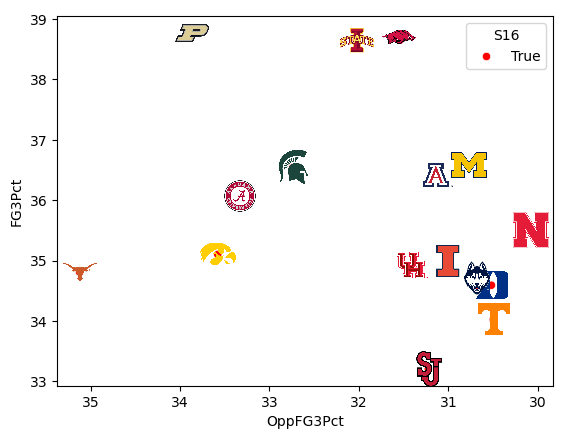

In [7]:
eff = tourney_teams[["Team","Seed", "FG3Pct", "OppFG3Pct", 'S16', 'logo']]
fig, ax = plt.subplots()
g = sns.scatterplot(data=eff[eff['S16'] == 1], x='OppFG3Pct', y='FG3Pct', hue='S16', palette={0: 'blue', 1: 'red'})
g.invert_xaxis()  # or g.invert_yaxis()
for i, row in eff.iterrows():
    if row['S16'] == 1:
        # Load image
        path = paths.ASSET_IMG_DIR / row['logo']
        img = plt.imread(path)
        im = OffsetImage(img, zoom=0.05) # Adjust zoom as necessary
        
        # Create AnnotationBbox
        ab = AnnotationBbox(im, (row['OppFG3Pct'], row['FG3Pct']), frameon=False)
        ax.add_artist(ab)
plt.show()


% of Points from 3 Allowed (y) vs % of Points from 3 Scored (x)

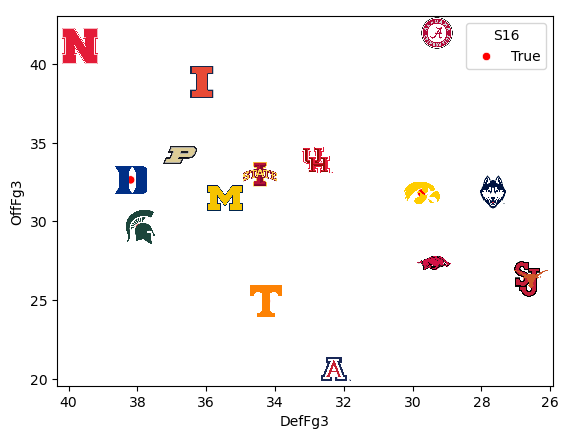

In [8]:

eff = tourney_teams[["Team","Seed", "DefFg3", "OffFg3", 'S16', 'logo']]
fig, ax = plt.subplots()
g = sns.scatterplot(data=eff[eff['S16'] == 1], x='DefFg3', y='OffFg3', hue='S16', palette={0: 'blue', 1: 'red'})
g.invert_xaxis()  # or g.invert_yaxis()
for i, row in eff.iterrows():
    if row['S16'] == 1:
        # Load image
        path = paths.ASSET_IMG_DIR / row['logo']
        img = plt.imread(path)
        im = OffsetImage(img, zoom=0.05) # Adjust zoom as necessary
        
        # Create AnnotationBbox
        ab = AnnotationBbox(im, (row['DefFg3'], row['OffFg3']), frameon=False)
        ax.add_artist(ab)
plt.show()

Insight: Nebraska scores over 40% of their points from 3 but also allows opponents to score over 40% from 3.